In [16]:

import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ============================================================
#  Basic setup
# ============================================================

def reset_seeds(seed=0):
    """Reset RNGs so runs are reproducible and decoupled."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
reset_seeds(0)

# ============================================================
#  Synthetic data with known transport T_true
# ============================================================

def sample_gaussian_mixture(n_samples, std=0.4):
    """
    2D binary classification: mixture of 2 Gaussians.
    """
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = torch.tensor([-1.0, 0.0])
    mean1 = torch.tensor([+1.0, 0.0])

    x0 = std * torch.randn(n0, 2) + mean0
    x1 = std * torch.randn(n1, 2) + mean1

    x = torch.cat([x0, x1], dim=0)
    y = torch.cat([
        torch.zeros(n0, dtype=torch.long),
        torch.ones(n1, dtype=torch.long)
    ], dim=0)

    perm = torch.randperm(n_samples)
    return x[perm], y[perm]


# Define a known smooth transport map T_true: rotation + translation
theta_deg = 30.0
theta_rad = math.radians(theta_deg)
R_true = torch.tensor([
    [math.cos(theta_rad), -math.sin(theta_rad)],
    [math.sin(theta_rad),  math.cos(theta_rad)]
])
u_true = torch.tensor([0.5, 0.2])


def T_true(x):
    """
    Known covariate shift: x -> R_true x + u_true
    x: (..., 2)
    """
    R = R_true.to(x.device)
    u = u_true.to(x.device)
    return x @ R.T + u


# Generate train / test data
N_TRAIN = 4000
N_TEST = 1000

train_x, train_y = sample_gaussian_mixture(N_TRAIN)
test_x, test_y = sample_gaussian_mixture(N_TEST)

# ============================================================
#  Dataset / DataLoader
# ============================================================

class IndexedTensorDataset(Dataset):
    """
    Returns (x, y, idx) so we can keep per-sample state.
    """
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], idx


BATCH_SIZE = 128
train_dataset = IndexedTensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ============================================================
#  Models: classifier and ICNN
# ============================================================

class MLPClassifier(nn.Module):
    def __init__(self, in_dim=2, hidden=64, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------------------
#  Principled ICNN components (ported from MNIST notebook)
# ------------------------------------------------------------

def icnn_principled_moments(fan_in: int):
    """Match icnn_principled_moments from MNIST.ipynb for positive weights."""
    if fan_in <= 0:
        raise ValueError(f"ICNN fan-in must be positive; got {fan_in}.")
    denom_offset = 6.0 * (math.pi - 1.0)
    denom_slope = 3.0 * math.sqrt(3.0) + 2.0 * math.pi - 6.0
    denom = denom_offset + (fan_in - 1.0) * denom_slope
    mu_w = math.sqrt((6.0 * math.pi) / (fan_in * denom))
    sigma_w2 = 1.0 / float(fan_in)
    mu_b = math.sqrt((3.0 * fan_in) / denom)
    mu_w_sq = mu_w * mu_w
    log_var_plus_mean_sq = math.log(sigma_w2 + mu_w_sq)
    log_mean_sq = math.log(mu_w_sq)
    tilde_mu = log_mean_sq - 0.5 * log_var_plus_mean_sq
    tilde_sigma2 = max(log_var_plus_mean_sq - log_mean_sq, 1e-12)
    tilde_sigma = math.sqrt(tilde_sigma2)
    return mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma


class NonNegativeLinear(nn.Module):
    """Linear map with strictly non-negative weights via exp/softplus."""
    def __init__(self, in_features, out_features, bias=True, init_mode="principled"):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = bias
        self.init_mode = init_mode.lower()
        if self.init_mode not in {"principled", "xavier"}:
            raise ValueError(f"Unsupported init_mode '{init_mode}' for NonNegativeLinear.")
        self.parametrization = "exp" if self.init_mode == "principled" else "softplus"

        self.weight_param = nn.Parameter(torch.empty(in_features, out_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self.reset_parameters()

    def reset_parameters(self):
        if self.init_mode == "principled":
            mu_w, sigma_w2, mu_b, tilde_mu, tilde_sigma = icnn_principled_moments(self.in_features)
            with torch.no_grad():
                if tilde_sigma == 0.0:
                    self.weight_param.fill_(tilde_mu)
                else:
                    self.weight_param.normal_(mean=tilde_mu, std=tilde_sigma)
                if self.bias is not None:
                    self.bias.fill_(mu_b)
        else:
            nn.init.xavier_uniform_(self.weight_param)
            if self.bias is not None:
                nn.init.zeros_(self.bias)

    def forward(self, x):
        weight = torch.exp(self.weight_param) if self.parametrization == "exp" else F.softplus(self.weight_param)
        y = x.matmul(weight)
        if self.bias is not None:
            y = y + self.bias
        return y


class InputConvexPotential(nn.Module):
    """
    Dense ICNN potential φ(z) mirroring MNIST.ipynb:
    - Non-negative hidden couplings with principled init
    - Softplus activation with adjustable beta
    - Quadratic strong-convexity term
    """
    def __init__(
        self,
        input_dim=2,
        hidden_sizes=(64, 64, 64),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=20.0,
    ):
        super().__init__()
        if len(hidden_sizes) == 0:
            raise ValueError("ICNN requires at least one hidden layer.")
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.activation = activation
        self.strong_convexity = strong_convexity
        self.softplus_beta = softplus_beta

        self.z_linears = nn.ModuleList()
        self.h_linears = nn.ModuleList()
        for i, width in enumerate(hidden_sizes):
            self.z_linears.append(nn.Linear(input_dim, width, bias=True))
            if i == 0:
                self.h_linears.append(None)
            else:
                self.h_linears.append(
                    NonNegativeLinear(
                        hidden_sizes[i - 1],
                        width,
                        bias=False,
                        init_mode=nonneg_init,
                    )
                )

        self.hidden_output = NonNegativeLinear(
            hidden_sizes[-1],
            1,
            bias=True,
            init_mode=nonneg_init,
        )
        self.input_skip = nn.Linear(input_dim, 1, bias=True)

    def _activation(self):
        act_name = self.activation.lower()
        if act_name == "relu":
            return F.relu
        if act_name == "softplus":
            beta = float(self.softplus_beta)
            return lambda u: F.softplus(beta * u) / beta
        raise ValueError(f"Unsupported ICNN activation '{self.activation}'.")

    def forward(self, x):
        z = x.view(x.size(0), -1)
        act = self._activation()

        h = act(self.z_linears[0](z))
        for k in range(1, len(self.z_linears)):
            z_term = self.z_linears[k](z)
            h_term = self.h_linears[k](h) if self.h_linears[k] is not None else 0.0
            h = act(z_term + h_term)

        quadratic = 0.5 * self.strong_convexity * (z ** 2).sum(dim=1, keepdim=True)
        out = quadratic + self.input_skip(z) + self.hidden_output(h)
        return out.squeeze(-1)


# Keep the original ICNN name for downstream code
ICNN = InputConvexPotential


def icnn_transport(icnn, x, create_graph=False):
    """
    Compute T(x) = ∇_x φ(x) via autograd.
    Returns T(x) with same shape as x.
    """
    x_ = x.clone().detach().requires_grad_(True)
    phi = icnn(x_)
    grads = torch.autograd.grad(
        outputs=phi.sum(),
        inputs=x_,
        create_graph=create_graph
    )[0]
    return grads.view_as(x)

# ============================================================
#  Training: standard classifier (no robustness)
# ============================================================

def train_standard(model, train_loader, num_epochs=30, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        for x, y, idx in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

# ============================================================
#  Algorithm 1: Particle ascent (per-batch)
# ============================================================

def _particle_ascent_grad(model, x_adv, y, x_orig, lam):
    """Per-sample gradient of ce - λ||x−x_orig||² with a normalized step."""
    logits = model(x_adv)
    ce = F.cross_entropy(logits, y, reduction='none')
    reg = ((x_adv - x_orig) ** 2).sum(dim=1)
    obj = (ce - lam * reg).sum()
    grad_x = torch.autograd.grad(obj, x_adv)[0]
    grad_norm = grad_x.view(grad_x.size(0), -1).norm(dim=1, keepdim=True)
    grad_norm = grad_norm.clamp(min=1e-8)
    return grad_x / grad_norm


def train_particle_ascent(model,
                          train_loader,
                          lam=0.5,
                          inner_steps=5,
                          inner_step_size=0.05,
                          num_epochs=30,
                          stateful=False,
                          x_full=None):
    """
    Algorithm 1 from the note:
    - inner maximization on x via gradient ascent;
    - outer minimization on θ via gradient descent.
    Optionally 'stateful' keeps a persistent adversarial particle per training point.
    """
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

    if stateful:
        assert x_full is not None
        adv_points = x_full.clone().to(device)  # per-sample adversarial state
    else:
        adv_points = None

    for epoch in range(num_epochs):
        model.train()
        for x, y, idx in train_loader:
            x = x.to(device)
            y = y.to(device)

            if stateful:
                # start from stored adversarial state
                x_start = adv_points[idx].detach()
            else:
                x_start = x.detach()

            x_adv = x_start.clone().detach().requires_grad_(True)
            x_orig = x.clone().detach()

            for s in range(1, inner_steps + 1):
                grad_x = _particle_ascent_grad(model, x_adv, y, x_orig, lam)
                step = inner_step_size / math.sqrt(s)
                x_adv = x_adv + step * grad_x
                x_adv = x_adv.detach().requires_grad_(True)

            if stateful:
                adv_points[idx] = x_adv.detach()

            # outer update on θ
            logits_outer = model(x_adv.detach())
            loss_outer = F.cross_entropy(logits_outer, y)

            optimizer.zero_grad()
            loss_outer.backward()
            optimizer.step()

    return model, adv_points


# helper: attack using trained classifier (for evaluation)
def particle_attack(model, x, y, lam=0.5, inner_steps=5, inner_step_size=0.05):
    model.eval()
    x_orig = x.clone().detach().to(device)
    y = y.to(device)

    x_adv = x_orig.clone().detach().requires_grad_(True)
    for s in range(1, inner_steps + 1):
        grad_x = _particle_ascent_grad(model, x_adv, y, x_orig, lam)
        step = inner_step_size / math.sqrt(s)
        x_adv = x_adv + step * grad_x
        x_adv = x_adv.detach().requires_grad_(True)
    return x_adv.detach()


# ============================================================
#  Algorithm 2: ICNN-based transport map
# ============================================================

def train_icnn_method(model,
                      icnn,
                      train_loader,
                      lam=0.5,
                      num_epochs=30,
                      lr_theta=1e-3,
                      lr_omega=1e-3,
                      inner_steps_icnn=5):
    """
    Algorithm 2 from the note:
      min_θ max_ω E[ ℓ(θ, T_ω(x)) - λ ||x - T_ω(x)||^2 ]
      where T_ω(x) = ∇φ_ω(x).

      inner_steps_icnn: gradient-ascent steps on ω per batch.
    """
    model.to(device)
    icnn.to(device)

    opt_theta = torch.optim.SGD(model.parameters(), lr=lr_theta)
    opt_omega = torch.optim.SGD(icnn.parameters(), lr=lr_omega)

    for epoch in range(num_epochs):
        for x, y, idx in train_loader:
            x = x.to(device)
            y = y.to(device)

            # ---- Step 1: gradient ascent on ω (adversary) ----
            # J(θ, ω) = E[ℓ(θ, T_ω(x)) - λ ||x - T_ω(x)||^2]
            for _ in range(inner_steps_icnn):
                x_w = x.clone().detach()
                T_x = icnn_transport(icnn, x_w, create_graph=True)
                logits_adv = model(T_x)
                ce_adv = F.cross_entropy(logits_adv, y, reduction='mean')
                reg = ((T_x - x_w) ** 2).sum(dim=1).mean()
                J = ce_adv - lam * reg

                opt_theta.zero_grad()
                opt_omega.zero_grad()
                J.backward()
                opt_omega.step()  # only ω is updated
                opt_theta.zero_grad()

            # ---- Step 2: gradient descent on θ (classifier) ----
            # use current adversarial map but detach from ω
            T_x_detached = icnn_transport(icnn, x, create_graph=False).detach()
            logits = model(T_x_detached)
            loss_theta = F.cross_entropy(logits, y, reduction='mean')

            opt_theta.zero_grad()
            loss_theta.backward()
            opt_theta.step()

    return model, icnn


# ============================================================
#  Evaluation utilities
# ============================================================

def evaluate_accuracy(model, x, y, batch_size=256):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for i in range(0, x.size(0), batch_size):
            xb = x[i:i + batch_size].to(device)
            yb = y[i:i + batch_size].to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()
    return correct / total


def evaluate_adv_accuracy_particle(model, x, y,
                                   lam=0.5,
                                   inner_steps=5,
                                   inner_step_size=0.05,
                                   batch_size=256):
    model.eval()
    total = 0
    correct = 0
    for i in range(0, x.size(0), batch_size):
        xb = x[i:i + batch_size]
        yb = y[i:i + batch_size]
        x_adv = particle_attack(model, xb, yb, lam=lam,
                                inner_steps=inner_steps,
                                inner_step_size=inner_step_size)
        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb.to(device)).sum().item()
    return correct / total


def evaluate_adv_accuracy_icnn(model, icnn, x, y, batch_size=256):
    model.eval()
    icnn.eval()
    total = 0
    correct = 0
    for i in range(0, x.size(0), batch_size):
        xb = x[i:i + batch_size].to(device)
        yb = y[i:i + batch_size].to(device)
        T_x = icnn_transport(icnn, xb, create_graph=False).detach()
        with torch.no_grad():
            logits = model(T_x)
            preds = logits.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()
    return correct / total


def transport_error_icnn(icnn, x, T_true_fn, sample_size=2000):
    icnn.eval()
    n = min(sample_size, x.size(0))
    xb = x[:n].to(device)
    T_true_x = T_true_fn(xb)
    T_learn = icnn_transport(icnn, xb, create_graph=False).detach()
    err = ((T_learn - T_true_x) ** 2).sum(dim=1).sqrt().mean().item()
    return err


def transport_error_particle(model, x, y, T_true_fn,
                             lam=0.5,
                             inner_steps=5,
                             inner_step_size=0.05,
                             sample_size=2000):
    n = min(sample_size, x.size(0))
    xb = x[:n]
    yb = y[:n]
    x_adv = particle_attack(model, xb, yb, lam=lam,
                            inner_steps=inner_steps,
                            inner_step_size=inner_step_size)
    T_true_x = T_true_fn(xb.to(device))
    err = ((x_adv - T_true_x) ** 2).sum(dim=1).sqrt().mean().item()
    return err

# ============================================================
#  Run experiment
# ============================================================

if __name__ == "__main__":
    # shift test data with known transport
    test_x_shifted = T_true(test_x)

    # ---------- baseline (no robustness) ----------
    reset_seeds(1)
    base_model = MLPClassifier()
    base_model = train_standard(base_model, train_loader, num_epochs=30, lr=1e-3)

    base_clean = evaluate_accuracy(base_model, test_x, test_y)
    base_shift = evaluate_accuracy(base_model, test_x_shifted, test_y)

    print("=== Baseline (no robustness) ===")
    print(f"Clean test accuracy:   {base_clean:.4f}")
    print(f"Shifted test accuracy: {base_shift:.4f}")
    print()

    # ---------- Algorithm 1: particle ascent ----------
    reset_seeds(2)
    lam = 0.005
    inner_steps = 20
    inner_step_size = 0.05

    alg1_model = MLPClassifier()
    alg1_model, _ = train_particle_ascent(
        alg1_model,
        train_loader,
        lam=lam,
        inner_steps=inner_steps,
        inner_step_size=inner_step_size,
        num_epochs=3,
        stateful=False,
        x_full=train_x
    )

    alg1_clean = evaluate_accuracy(alg1_model, test_x, test_y)
    alg1_shift = evaluate_accuracy(alg1_model, test_x_shifted, test_y)
    alg1_adv = evaluate_adv_accuracy_particle(
        alg1_model, test_x, test_y,
        lam=lam,
        inner_steps=inner_steps,
        inner_step_size=inner_step_size
    )

    alg1_T_err = transport_error_particle(
        alg1_model, test_x, test_y,
        T_true_fn=T_true,
        lam=lam,
        inner_steps=inner_steps,
        inner_step_size=inner_step_size
    )

    print("=== Algorithm 1: Particle Ascent ===")
    print(f"Clean test accuracy:         {alg1_clean:.4f}")
    print(f"Shifted test accuracy:       {alg1_shift:.4f}")
    print(f"Adversarial test accuracy:   {alg1_adv:.4f}")
    print(f"Transport error vs T_true:   {alg1_T_err:.4f}")
    print()

    # ---------- Algorithm 2: ICNN-based transport map ----------
    reset_seeds(3)
    icnn = ICNN(
        input_dim=2,
        hidden_sizes=(64, 64),
        activation="softplus",
        strong_convexity=1.0,
        nonneg_init="principled",
        softplus_beta=1.0,
    )
    alg2_model = MLPClassifier()

    alg2_model, icnn = train_icnn_method(
        alg2_model,
        icnn,
        train_loader,
        lam=lam,
        num_epochs=2,
        lr_theta=1e-2,
        lr_omega=1e-3,
        inner_steps_icnn=3
    )

    alg2_clean = evaluate_accuracy(alg2_model, test_x, test_y)
    alg2_shift = evaluate_accuracy(alg2_model, test_x_shifted, test_y)
    alg2_adv = evaluate_adv_accuracy_icnn(alg2_model, icnn, test_x, test_y)
    alg2_T_err = transport_error_icnn(icnn, test_x, T_true_fn=T_true)

    print("=== Algorithm 2: ICNN Transport Map ===")
    print(f"Clean test accuracy:         {alg2_clean:.4f}")
    print(f"Shifted test accuracy:       {alg2_shift:.4f}")
    print(f"Adversarial test accuracy:   {alg2_adv:.4f}")
    print(f"Transport error vs T_true:   {alg2_T_err:.4f}")
    print()

    # ---------- Prepare cached tensors for visualization ----------
    viz_n = 800
    viz_indices = torch.randperm(test_x.size(0))[:viz_n]
    viz_x = test_x[viz_indices]
    viz_y = test_y[viz_indices]

    adv_alg1 = particle_attack(
        alg1_model,
        viz_x,
        viz_y,
        lam=lam,
        inner_steps=inner_steps,
        inner_step_size=inner_step_size
    ).cpu()
    map_alg2 = icnn_transport(
        icnn,
        viz_x.to(device),
        create_graph=False
    ).detach().cpu()
    true_shift = T_true(viz_x).cpu()

    plot_cache = {
        "train_x": train_x.cpu(),
        "train_y": train_y.cpu(),
        "test_x": test_x.cpu(),
        "test_y": test_y.cpu(),
        "test_x_shifted": test_x_shifted.cpu(),
        "viz_x": viz_x.cpu(),
        "viz_y": viz_y.cpu(),
        "adv_alg1": adv_alg1,
        "map_alg2": map_alg2,
        "true_shift": true_shift,
        "lam": lam,
        "inner_steps": inner_steps,
        "inner_step_size": inner_step_size,
    }

    print("Plot cache prepared. Run the visualization cells to see the distributions and adversarial maps.")


=== Baseline (no robustness) ===
Clean test accuracy:   0.9930
Shifted test accuracy: 0.9090

=== Algorithm 1: Particle Ascent ===
Clean test accuracy:         0.9920
Shifted test accuracy:       0.9250
Adversarial test accuracy:   0.9280
Transport error vs T_true:   0.7583

=== Algorithm 2: ICNN Transport Map ===
Clean test accuracy:         0.9770
Shifted test accuracy:       0.9530
Adversarial test accuracy:   0.9820
Transport error vs T_true:   0.6307

Plot cache prepared. Run the visualization cells to see the distributions and adversarial maps.


## Plotting utilities
Helper routines for consistent styling and for visualizing the covariate shift and adversarial transports.

In [17]:

import math
from typing import Dict

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from matplotlib.lines import Line2D

CLASS_COLORS = {0: "#2a9d8f", 1: "#e76f51"}
POINT_KWARGS = dict(alpha=0.78, edgecolor="white", linewidth=0.85, s=36)


def set_plot_style():
    sns.set_theme(context="talk", style="whitegrid", palette="colorblind")
    mpl.rcParams.update({
        "axes.facecolor": "#f8f9fb",
        "figure.facecolor": "white",
        "grid.alpha": 0.25,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    })


def _scatter_by_class(ax, x, y, label_prefix="", marker="o", size=36, zorder=2, alpha=None):
    alpha = POINT_KWARGS["alpha"] if alpha is None else alpha
    handles = []
    for cls in torch.unique(y):
        cls_int = int(cls.item())
        mask = (y == cls)
        handle = ax.scatter(
            x[mask, 0].cpu(),
            x[mask, 1].cpu(),
            c=CLASS_COLORS.get(cls_int, "#4c78a8"),
            marker=marker,
            s=size,
            alpha=alpha,
            linewidth=POINT_KWARGS["linewidth"],
            edgecolor=POINT_KWARGS["edgecolor"],
            label=f"{label_prefix} class {cls_int}",
            zorder=zorder,
        )
        handles.append(handle)
    ax.set_aspect("equal", adjustable="box")
    return handles


def _quiver_overlays(ax, start, end, color, max_vectors=60, alpha=0.6, label=None):
    if start.size(0) == 0:
        return None
    n = min(max_vectors, start.size(0))
    indices = torch.linspace(0, start.size(0) - 1, steps=n).long()
    origin = start[indices].cpu()
    disp = (end[indices] - start[indices]).cpu()
    q = ax.quiver(
        origin[:, 0],
        origin[:, 1],
        disp[:, 0],
        disp[:, 1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        alpha=alpha,
        width=0.0045,
        zorder=1,
    )
    if label:
        q.set_label(label)
    return q


def _set_axis_limits(ax, tensors, padding=0.6):
    stacked = torch.cat([t.view(-1, 2) for t in tensors if t is not None], dim=0)
    mins = stacked.min(dim=0).values - padding
    maxs = stacked.max(dim=0).values + padding
    ax.set_xlim(float(mins[0]), float(maxs[0]))
    ax.set_ylim(float(mins[1]), float(maxs[1]))


def plot_initial_distributions(cache: Dict[str, torch.Tensor]):
    train_x = cache["train_x"]
    train_y = cache["train_y"]
    test_x = cache["test_x"]
    test_y = cache["test_y"]
    shifted = cache["test_x_shifted"]

    preview = min(700, test_x.size(0))
    idx = torch.randperm(test_x.size(0))[:preview]
    test_x_small = test_x[idx]
    test_y_small = test_y[idx]
    shifted_small = shifted[idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

    h1 = _scatter_by_class(axes[0], train_x, train_y, label_prefix="train")
    h2 = _scatter_by_class(axes[0], test_x_small, test_y_small, label_prefix="test", marker="^", size=30, alpha=0.65)
    axes[0].set_title("Original train/test mixture")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].legend(handles=h1[:1] + h2[:1], frameon=False, loc="upper right", title="Legend")

    _scatter_by_class(axes[1], shifted_small, test_y_small, label_prefix="shifted test", marker="^", size=34, alpha=0.8)
    _quiver_overlays(axes[1], test_x_small, shifted_small, color="#264653", max_vectors=80, alpha=0.45, label="$T_{true}$")
    axes[1].set_title("Covariate shift $T_{true}$ applied to test set")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    axes[1].legend(frameon=False, loc="upper right")

    _set_axis_limits(axes[0], [train_x, test_x_small, shifted_small])
    _set_axis_limits(axes[1], [train_x, test_x_small, shifted_small])

    fig.suptitle("Synthetic mixture and target covariate shift", fontsize=15, y=1.02)
    fig.tight_layout()
    return fig


def plot_adversarial_overlays(cache: Dict[str, torch.Tensor]):
    base = cache["viz_x"]
    labels = cache["viz_y"]
    adv_alg1 = cache["adv_alg1"]
    map_alg2 = cache["map_alg2"]
    true_shift = cache["true_shift"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

    # ground-truth shift
    _scatter_by_class(axes[0], base, labels, label_prefix="orig")
    _scatter_by_class(axes[0], true_shift, labels, label_prefix="true shift", marker="X", size=54, alpha=0.78, zorder=3)
    _quiver_overlays(axes[0], base, true_shift, color="#264653", max_vectors=70, alpha=0.4)
    axes[0].set_title("Known transport $T_{true}$")

    # algorithm 1
    _scatter_by_class(axes[1], base, labels, label_prefix="orig")
    _scatter_by_class(axes[1], adv_alg1, labels, label_prefix="alg1 adv", marker="^", size=40, alpha=0.82, zorder=3)
    _quiver_overlays(axes[1], base, adv_alg1, color="#e76f51", max_vectors=70, alpha=0.55, label="Alg. 1")
    axes[1].set_title("Algorithm 1: particle ascent")

    # algorithm 2
    _scatter_by_class(axes[2], base, labels, label_prefix="orig")
    _scatter_by_class(axes[2], map_alg2, labels, label_prefix="ICNN map", marker="^", size=40, alpha=0.82, zorder=3)
    _quiver_overlays(axes[2], base, true_shift, color="#2a9d8f", max_vectors=40, alpha=0.35, label="True shift")
    _quiver_overlays(axes[2], base, map_alg2, color="#577590", max_vectors=70, alpha=0.65, label="Alg. 2 map")
    axes[2].set_title("Algorithm 2: ICNN transport map")

    handles = [
        Line2D([0], [0], marker='o', color='w', label='original', markerfacecolor='#4c78a8', markersize=8, markeredgecolor='white'),
        Line2D([0], [0], marker='^', color='w', label='adv/map', markerfacecolor='#e76f51', markersize=8, markeredgecolor='white'),
        Line2D([0], [0], marker='X', color='w', label='$T_{true}(x)$', markerfacecolor='#264653', markersize=9, markeredgecolor='white'),
        Line2D([0], [0], linestyle='-', color='#577590', label='displacement'),
    ]
    axes[2].legend(handles=handles, frameon=False, loc="upper right")

    for ax in axes:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")

    _set_axis_limits(axes[0], [base, adv_alg1, map_alg2, true_shift])
    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.22)

    fig.suptitle("Adversarial transports vs. ground-truth shift", fontsize=15, y=1.02)
    fig.tight_layout()
    return fig


## Visualize covariate shift and adversarial points
Run this after the training cell to generate the plots.

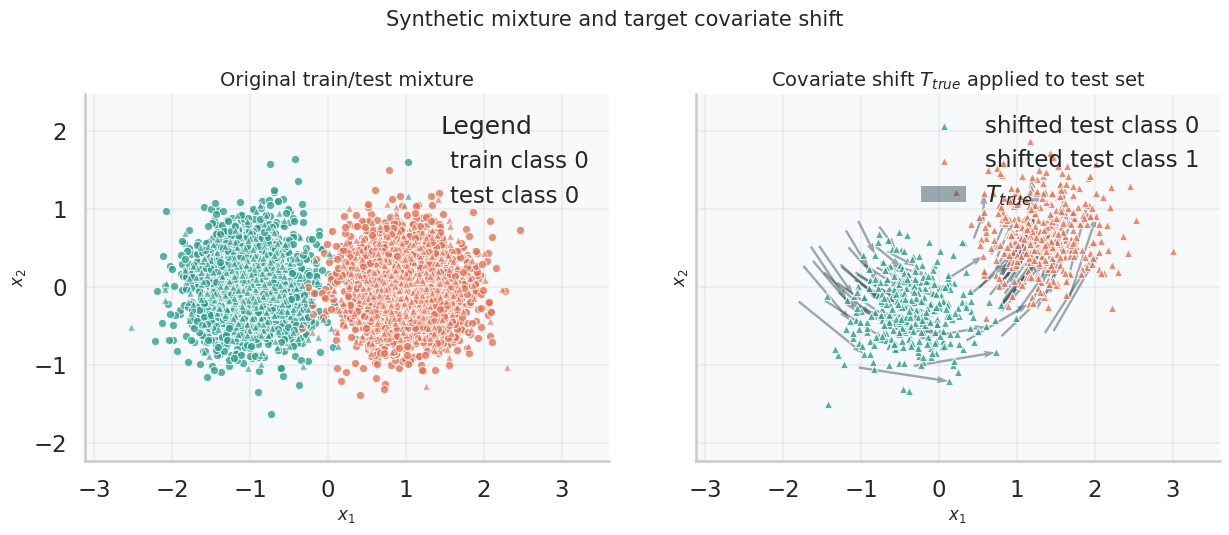

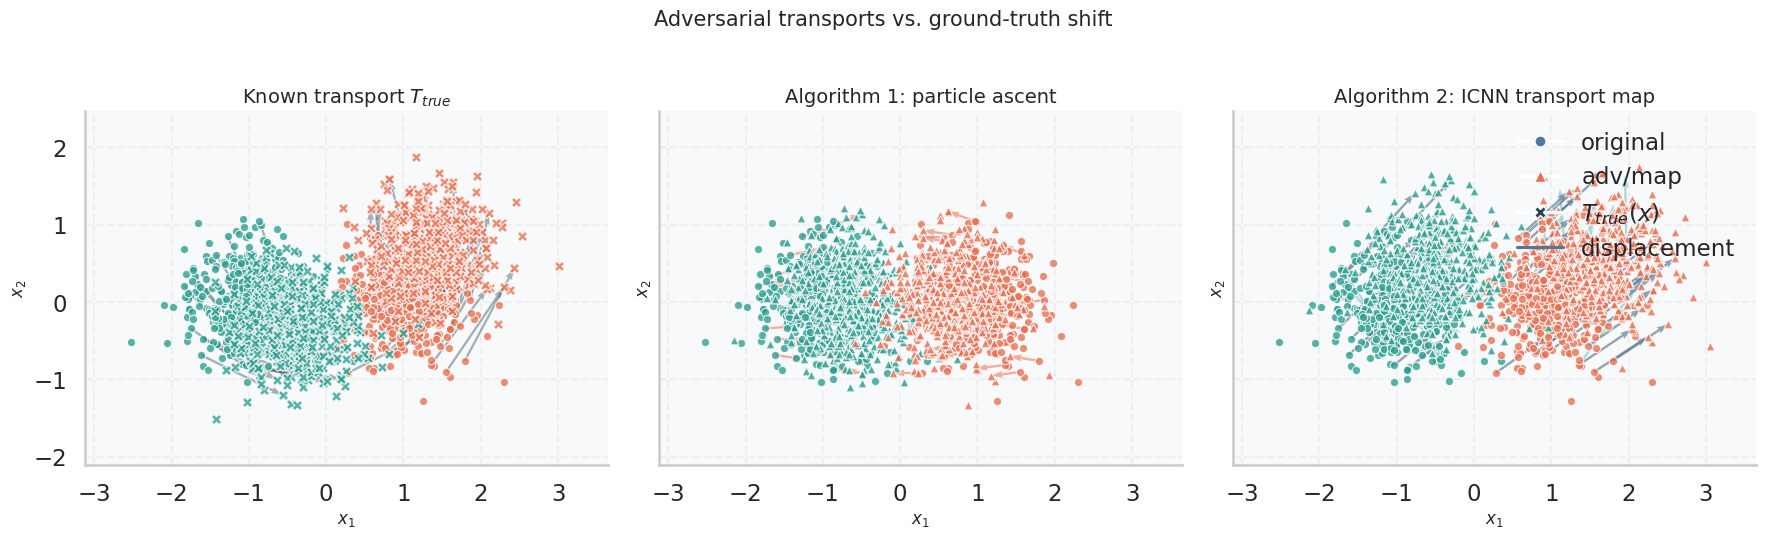

In [18]:

if "plot_cache" not in globals():
    raise RuntimeError("Run the training cell above to populate plot_cache.")

set_plot_style()
fig_data = plot_initial_distributions(plot_cache)
fig_adv = plot_adversarial_overlays(plot_cache)
plt.show()
